In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import cv2 as cv
from glob import glob
from torch.utils.data import Dataset, DataLoader
from diffusers.models import UNet2DModel, AutoencoderTiny
from diffusers.schedulers.scheduling_dpmsolver_multistep import DPMSolverMultistepScheduler
from torchvision.utils import make_grid
from torchvision.transforms import functional as tvf
# from torchvision.transforms import 
import os
import random
import matplotlib.pyplot as plt
from tqdm import tqdm
import numpy as np
# from torch.cuda.amp import autocast, GradScaler
from torch import autocast
from torch.amp import GradScaler

from typing import Optional, Union, List, Tuple


/home/dhester/diffusion-examples/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
class StandardDataAugmentations:
    '''
    Simple data augmentation that applies random rotation, horizontal, and vertical flips.
    '''
    
    @staticmethod
    def __call__(X: torch.Tensor, y: Optional[torch.Tensor] = None):
        
        # do not resize this time, just apply random flip and color distortions
        if torch.rand(1) > 0.5:
            X = tvf.hflip(X)
            if y is not None:
                y = tvf.hflip(y)
        
        if torch.rand(1) > 0.5:
            X = tvf.vflip(X)
            if y is not None:
                y = tvf.vflip(y)
        
        rot_angle = torch.randint(0, 4, (1,)).item()
        X = tvf.rotate(X, rot_angle * 90)
        if y is not None:
            y = tvf.rotate(y, rot_angle * 90)
    
        
        if y is not None:
            return X, y
        return X
    
class PlanetDataset(Dataset):
    
    def __init__(self, s2_filepaths: Union[List[str], Tuple[str]], ps_filepaths: Union[List[str], Tuple[str]], transforms: Optional[StandardDataAugmentations] = None):
        super().__init__()
        
        self.s2_filepaths = s2_filepaths
        self.ps_filepaths = ps_filepaths
        self.transforms = transforms
        
    def __len__(self):
        return len(self.s2_filepaths)
        
    @staticmethod
    def _scale(
        data, 
        in_range: Union[Tuple[int, int], Tuple[float, float]]=(0, 255), 
        out_range: Union[Tuple[int, int], Tuple[float, float]]=(-1.0, 1.0)
    ) -> torch.Tensor:
        
        # scale to 0-1
        data = (data - in_range[0]) / (in_range[1] - in_range[0])
        
        # scale to out_range
        data = data * (out_range[1] - out_range[0]) + out_range[0]
        data = data.clamp(min=out_range[0], max=out_range[1])
        return data
    
    def get_s2_img(self, idx):
        
        s2_img = cv.imread(self.s2_filepaths[idx])
        s2_img = cv.cvtColor(s2_img, cv.COLOR_BGR2RGB)
        
        s2_img = torch.as_tensor(s2_img, dtype=torch.float32)
        s2_img = s2_img.permute(2, 0, 1)
        return self._scale(s2_img)
    
    def get_ps_img(self, idx, harmonize: bool=False, return_s2_img: bool=False):
        
        if return_s2_img and not harmonize:
            raise ValueError('Cannot return Sentinel-2 image when harmonize is set to False')
        
        ps_img = cv.imread(self.ps_filepaths[idx])
        ps_img = cv.cvtColor(ps_img, cv.COLOR_BGR2RGB)

        ps_img = torch.as_tensor(ps_img, dtype=torch.float32)
        ps_img = self._scale(ps_img)
        ps_img = ps_img.permute(2, 0, 1)
        return ps_img
    
    
    def __getitem__(self, idx):
        # return self.get_ps_img(idx, harmonize=True, return_s2_img=True)
        s2_img, ps_img = self.get_s2_img(idx), self.get_ps_img(idx)
        if self.transforms is not None:
            return self.transforms(s2_img, ps_img)
        else:
            return s2_img, ps_img


# s2_image_paths = glob('/Volumes/dhester_ssd/dakota_sample_training_sr_images/*/*/s2_patch_*.png')
# ps_image_paths = glob('/Volumes/dhester_ssd/dakota_sample_training_sr_images/*/*/ps_patch_*.png')
s2_image_paths = glob('../dakota_sample_training_sr_images/*/*/s2_patch_*.png')
ps_image_paths = [fp.replace('s2_patch_', 'ps_patch_').replace('.png', '_harmonized.png') for fp in s2_image_paths]


In [3]:
random.seed(1701)

unique_locations = set(path.split(os.sep)[-3] for path in s2_image_paths)
for unique_location in unique_locations:
    print(unique_location, len([path for path in s2_image_paths if path.split(os.sep)[-3] == unique_location]))

val_sites = random.sample(sorted(unique_locations), k=1)
train_sites = [site for site in unique_locations if site not in val_sites]

print(val_sites, train_sites)

15SXS 1770
10SGF 3935
13QGB 5712
11TQH 6314
13QGF 2490
16TFP 2919
17MNQ 5438
17SKR 4837
18TUL 4053
15TWH 967
['17MNQ'] ['15SXS', '10SGF', '13QGB', '11TQH', '13QGF', '16TFP', '17SKR', '18TUL', '15TWH']


In [4]:
train_s2_paths = [fp for fp in s2_image_paths if fp.split(os.sep)[-3] in train_sites]
train_ps_paths = [fp for fp in ps_image_paths if fp.split(os.sep)[-3] in train_sites]
train_dataset = PlanetDataset(train_s2_paths, train_ps_paths, transforms=StandardDataAugmentations())
print(f'Number of samples in training dataset: {len(train_dataset)}')

val_s2_paths = [fp for fp in s2_image_paths if fp.split(os.sep)[-3] in val_sites]
val_ps_paths = [fp for fp in ps_image_paths if fp.split(os.sep)[-3] in val_sites]
val_dataset = PlanetDataset(val_s2_paths, val_ps_paths)
print(f'Number of samples in validation dataset: {len(val_dataset)}')

Number of samples in training dataset: 32997
Number of samples in validation dataset: 5438


In [5]:
# device = torch.device('mps') if torch.backends.mps.is_available() else torch.device('cpu')
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print(f'Using backed {device}')
if device.type == 'cuda' and torch.cuda.is_bf16_supported():
    print('bfloat16 is supported. Using for mixed precision.')
    mixed_precision_dtype = torch.bfloat16
else:
    print('bfloat16 not supported. Falling back to float16 for mixed precision.')
    mixed_precision_dtype = torch.float16

model = UNet2DModel(
    sample_size=256,
    in_channels=3,
    out_channels=3,
    block_out_channels=[64, 128, 256, 512],
    down_block_types=['DownBlock2D'] * 4, # + ['AttnDownBlock2D'],
    up_block_types=['UpBlock2D'] * 4, # + ['AttnUpBlock2D']
)
model.to(device)
# model = torch.compile(model)

print(f'Total U-Net parameters: {sum([p.numel() for p in model.parameters()])}')

Using backed cuda
bfloat16 is supported. Using for mixed precision.
Total U-Net parameters: 56574595


In [ ]:
batch_size = 256
micro_batch_size = 32
n_epochs = 100
warmup_epochs = 10
lr = 1e-4

grad_accum_steps = batch_size // micro_batch_size

optimizer = torch.optim.AdamW(model.parameters(), lr=lr, fused=torch.cuda.is_available())
warmup_scheduler = torch.optim.lr_scheduler.LinearLR(optimizer, start_factor=0.1, end_factor=1.0, total_iters=warmup_epochs-1)
cosine_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_epochs - warmup_epochs)
lr_scheduler = torch.optim.lr_scheduler.SequentialLR(optimizer, schedulers=[warmup_scheduler, cosine_scheduler], milestones=[warmup_epochs])
# lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, n_epochs)
scaler = GradScaler()

train_dataloader = DataLoader(train_dataset, batch_size=micro_batch_size, shuffle=True, drop_last=True, pin_memory=True, num_workers=8)

losses = []
for epoch in range(1, n_epochs+1):
    
    model.train()
    epoch_losses = []
    with tqdm(train_dataloader, desc=f'Epoch {epoch}/{n_epochs}', unit='batch', postfix={'lr': optimizer.param_groups[0]['lr']}) as pbar:
        for i, (s2_img, ps_img) in enumerate(pbar):
            
            s2_img = F.interpolate(s2_img, size=ps_img.shape[-2:], mode='bilinear')
            s2_img, ps_img = s2_img.to(device), ps_img.to(device)
            
            t = torch.rand(micro_batch_size, device=device)
            t_reshaped = t.view(-1, 1, 1, 1)
            
            # interpolated point on the path (linear interpolation)
            x_t = (1 - t_reshaped) * s2_img + t_reshaped * ps_img
            target_vector = ps_img - s2_img # target vector field

            with autocast(device.type, dtype=mixed_precision_dtype):
                pred_vector = model(x_t, t * 999).sample
                loss = F.mse_loss(target_vector, pred_vector)

            scaler.scale(loss).backward()
            epoch_losses.append(loss.item())

            if (i + 1) % grad_accum_steps == 0:
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad()
            
            pbar.set_postfix(lr=optimizer.param_groups[0]['lr'], loss=sum(epoch_losses) / len(epoch_losses))
    
    torch.save(model.state_dict(), '../models/fm_s2_ps_sr_2.pt')
    losses.append(sum(epoch_losses) / len(epoch_losses))
    lr_scheduler.step()

    model.eval()
    n_samples = 8
    num_inference_timesteps = 10

    ps_img = torch.stack([val_dataset[i][1] for i in range(n_samples)], dim=0)

    s2_img = torch.stack([val_dataset[i][0] for i in range(n_samples)], dim=0)
    s2_img = F.interpolate(s2_img, size=ps_img.shape[-2:], mode='bilinear').to(device)

    timesteps = torch.linspace(0, 1, num_inference_timesteps, device=device)
    step_size = timesteps[1] - timesteps[0]

    # x = torch.randn_like(s2_img, device=device)
    x = s2_img
    for t in tqdm(timesteps):
        t_batch = torch.ones(n_samples, device=device) * t
        t_mid_batch = torch.ones(n_samples, device=device) * (t + step_size / 2)
        t_next_batch = torch.ones(n_samples, device=device) * (t + step_size)

        with torch.no_grad(), autocast(device.type, dtype=mixed_precision_dtype):
            
            # k1: velocity at start of the step
            v_k1 = model(x, t_batch * 999).sample
            
            # k2: velocity at midpoint
            x_k2 = x + v_k1 * (step_size / 2)
            v_k2 = model(x_k2, t_mid_batch * 999).sample
            
            # k3: velocity at midpoint (estimated with k2)
            x_k3 = x + v_k2 * (step_size / 2)
            v_k3 = model(x_k3, t_mid_batch * 999).sample
            
            # k4: velocity at the end of the step
            x_k4 = x + v_k3 * step_size
            v_k4 = model(x_k4, t_next_batch * 999).sample
        
        x = x + (step_size / 6) * (v_k1 + 2*v_k2 + 2*v_k3 + v_k4)
        
    fig, axes = plt.subplots(n_samples, 3, figsize=(6, 2*n_samples))

    for i, ax in enumerate(axes):
        
        # ax[0].imshow(s2_img)
        
        s2_img_display = (s2_img[i].clamp(-1, 1) + 1) / 2
        s2_img_display = s2_img_display.permute(1, 2, 0).cpu().numpy()
        s2_img_display = s2_img_display[:128, :128, :]
        ax[0].imshow(s2_img_display)
        
        output_display = (x[i].clamp(-1, 1) + 1) / 2
        output_display = output_display.permute(1, 2, 0).to(torch.float32).cpu().numpy()
        output_display = output_display[:128, :128, :]
        ax[1].imshow(output_display)
        
        ps_img_display = (ps_img[i].clamp(-1, 1) + 1) / 2
        ps_img_display = ps_img_display.permute(1, 2, 0).cpu().numpy()
        ps_img_display = ps_img_display[:128, :128, :]
        ax[2].imshow(ps_img_display)
        
        ax[0].axis('off')
        ax[1].axis('off')
        ax[2].axis('off')

    axes[0][0].set_title('Sentinel-2 Input')
    axes[0][1].set_title('Super-resolved Image')
    axes[0][2].set_title('PlanetScope Image')

    fig.suptitle(f'Epoch {epoch}/{n_epochs} | MSE = {sum(epoch_losses) / len(epoch_losses):.5f}\n')

    plt.tight_layout()
    plt.show()

In [28]:

def sr3_model_inference(x: torch.Tensor, model: nn.Module, num_timesteps: int = 10):
    """USe SR3 model for super-resolution using RK4 to solve ODE

    Args:
        x (torch.Tensor): Low resolution input
        model (torch.Module): SR3 Model
        num_timesteps (int, optional): Number of timesteps to use for . Defaults to 10.
    """
    
    device = model.device
    n_samples = x.shape[0]
    
    timesteps = torch.linspace(0, 1, num_timesteps, device=device)
    step_size = timesteps[1] - timesteps[0]
    
    lr_img = x.clone()
    x = torch.randn_like(lr_img, device=device)
    
    for t in tqdm(timesteps):
        t_batch = torch.ones(n_samples, device=device) * t
        t_mid_batch = torch.ones(n_samples, device=device) * (t + step_size / 2)
        t_next_batch = torch.ones(n_samples, device=device) * (t + step_size)

        with torch.no_grad(), autocast(device.type, dtype=mixed_precision_dtype):
            
            # k1: velocity at start of the step
            model_input_k1 = torch.cat((x, lr_img), dim=1)
            v_k1 = model(model_input_k1, t_batch * 999).sample
            
            # k2: velocity at midpoint
            x_k2 = x + v_k1 * (step_size / 2)
            model_input_k2 = torch.cat((x_k2, lr_img), dim=1)
            v_k2 = model(model_input_k2, t_mid_batch * 999).sample
            
            # k3: velocity at midpoint (estimated with k2)
            x_k3 = x + v_k2 * (step_size / 2)
            model_input_k3 = torch.cat((x_k3, lr_img), dim=1)
            v_k3 = model(model_input_k3, t_mid_batch * 999).sample
            
            # k4: velocity at the end of the step
            x_k4 = x + v_k3 * step_size
            model_input_k4 = torch.cat((x_k4, lr_img), dim=1)
            v_k4 = model(model_input_k4, t_next_batch * 999).sample
        
        x = x + (step_size / 6) * (v_k1 + 2*v_k2 + 2*v_k3 + v_k4)
    
    return x



def fm_model_inference(x: torch.Tensor, model: nn.Module, num_timesteps: int = 10):
    """USe flow matchin model for super-resolution using RK4 to solve ODE

    Args:
        x (torch.Tensor): Low resolution input
        model (torch.Module): Flow matching Model
        num_timesteps (int, optional): Number of timesteps to use for . Defaults to 10.
    """
    
    device = model.device
    n_samples = x.shape[0]
    
    timesteps = torch.linspace(0, 1, num_timesteps, device=device)
    step_size = timesteps[1] - timesteps[0]
    
    for t in tqdm(timesteps):
        t_batch = torch.ones(n_samples, device=device) * t
        t_mid_batch = torch.ones(n_samples, device=device) * (t + step_size / 2)
        t_next_batch = torch.ones(n_samples, device=device) * (t + step_size)

        with torch.no_grad(), autocast(device.type, dtype=mixed_precision_dtype):
            
            # k1: velocity at start of the step
            v_k1 = model(x, t_batch * 999).sample
            
            # k2: velocity at midpoint
            x_k2 = x + v_k1 * (step_size / 2)
            v_k2 = model(x_k2, t_mid_batch * 999).sample
            
            # k3: velocity at midpoint (estimated with k2)
            x_k3 = x + v_k2 * (step_size / 2)
            v_k3 = model(x_k3, t_mid_batch * 999).sample
            
            # k4: velocity at the end of the step
            x_k4 = x + v_k3 * step_size
            v_k4 = model(x_k4, t_next_batch * 999).sample
        
        x = x + (step_size / 6) * (v_k1 + 2*v_k2 + 2*v_k3 + v_k4)
    
    return x


In [27]:
sr3_model = UNet2DModel(
    sample_size=256,
    in_channels=6,
    out_channels=3,
    block_out_channels=[64, 128, 256, 512],
    down_block_types=['DownBlock2D'] * 4, # + ['AttnDownBlock2D'],
    up_block_types=['UpBlock2D'] * 4, # + ['AttnUpBlock2D']
)

sr3_weights = torch.load('../models/fm_s2_ps_sr.pt')
sr3_weights_adj = {}
for k in sr3_weights.keys():
    sr3_weights_adj[k.replace('_orig_mod.', '')] = sr3_weights[k]

sr3_model.load_state_dict(sr3_weights_adj)
sr3_model.to(device)
sr3_model.eval()

UNet2DModel(
  (conv_in): Conv2d(6, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (time_proj): Timesteps()
  (time_embedding): TimestepEmbedding(
    (linear_1): Linear(in_features=64, out_features=256, bias=True)
    (act): SiLU()
    (linear_2): Linear(in_features=256, out_features=256, bias=True)
  )
  (down_blocks): ModuleList(
    (0): DownBlock2D(
      (resnets): ModuleList(
        (0-1): 2 x ResnetBlock2D(
          (norm1): GroupNorm(32, 64, eps=1e-05, affine=True)
          (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (time_emb_proj): Linear(in_features=256, out_features=64, bias=True)
          (norm2): GroupNorm(32, 64, eps=1e-05, affine=True)
          (dropout): Dropout(p=0.0, inplace=False)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (nonlinearity): SiLU()
        )
      )
      (downsamplers): ModuleList(
        (0): Downsample2D(
          (conv): Conv2d(64, 64, ker

100%|██████████| 10/10 [00:08<00:00,  1.17it/s]


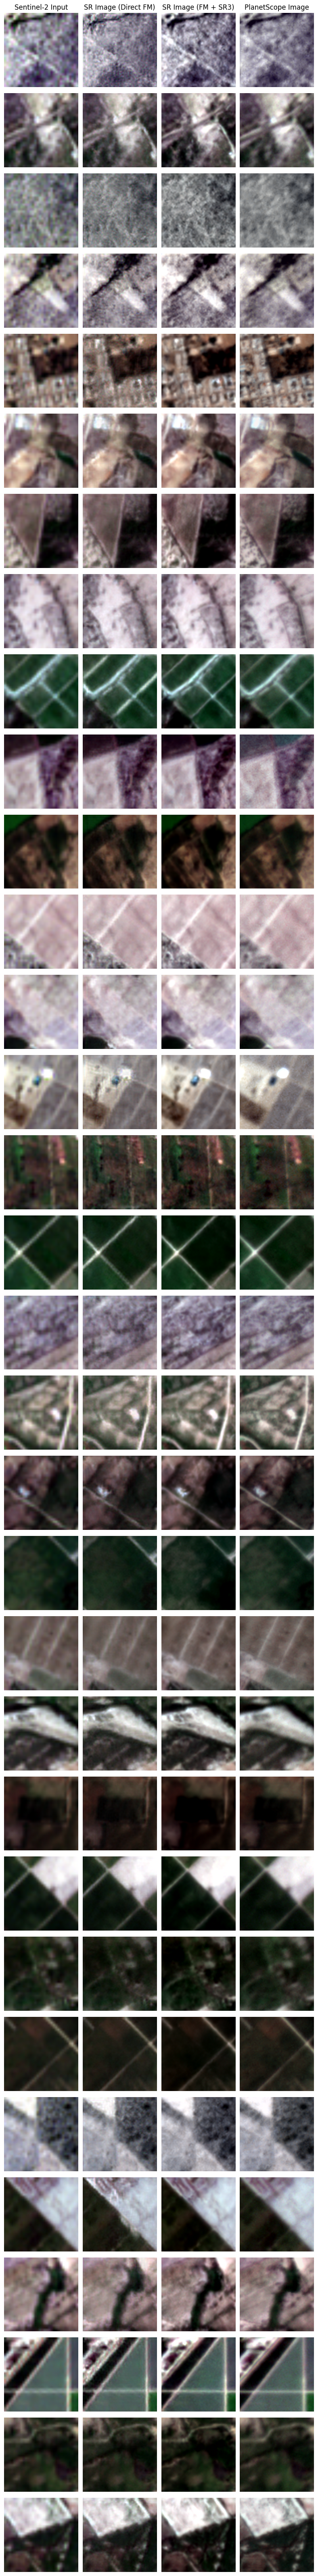

In [34]:
model.eval()

n_samples = 32
num_inference_timesteps = 20

ps_img = torch.stack([val_dataset[i][1] for i in range(n_samples)], dim=0)

s2_img = torch.stack([val_dataset[i][0] for i in range(n_samples)], dim=0)
s2_img = F.interpolate(s2_img, size=ps_img.shape[-2:], mode='bilinear').to(device)

sr3_output = sr3_model_inference(s2_img, sr3_model)
fm_output = fm_model_inference(s2_img, model)

fig, axes = plt.subplots(n_samples, 4, figsize=(8, 2*n_samples))

for i, ax in enumerate(axes):
    
    # ax[0].imshow(s2_img)
    
    s2_img_display = (s2_img[i].clamp(-1, 1) + 1) / 2
    s2_img_display = s2_img_display.permute(1, 2, 0).cpu().numpy()
    s2_img_display = s2_img_display[:128, :128, :]
    ax[0].imshow(s2_img_display)
    
    fm_output_display = (fm_output[i].clamp(-1, 1) + 1) / 2
    fm_output_display = fm_output_display.permute(1, 2, 0).to(torch.float32).cpu().numpy()
    fm_output_display = fm_output_display[:128, :128, :]
    ax[1].imshow(fm_output_display)
    
    sr3_output_display = (sr3_output[i].clamp(-1, 1) + 1) / 2
    sr3_output_display = sr3_output_display.permute(1, 2, 0).to(torch.float32).cpu().numpy()
    sr3_output_display = sr3_output_display[:128, :128, :]
    ax[2].imshow(sr3_output_display)
    
    ps_img_display = (ps_img[i].clamp(-1, 1) + 1) / 2
    ps_img_display = ps_img_display.permute(1, 2, 0).cpu().numpy()
    ps_img_display = ps_img_display[:128, :128, :]
    ax[3].imshow(ps_img_display)
    
    ax[0].axis('off')
    ax[1].axis('off')
    ax[2].axis('off')
    ax[3].axis('off')

axes[0][0].set_title('Sentinel-2 Input')
axes[0][1].set_title('SR Image (Direct FM)')
axes[0][2].set_title('SR Image (FM + SR3)')
axes[0][3].set_title('PlanetScope Image')

# fig.suptitle(f'Epoch {epoch}/{n_epochs} | MSE = {sum(epoch_losses) / len(epoch_losses):.5f}\n')

plt.tight_layout()
plt.show()

100%|██████████| 20/20 [00:15<00:00,  1.27it/s]


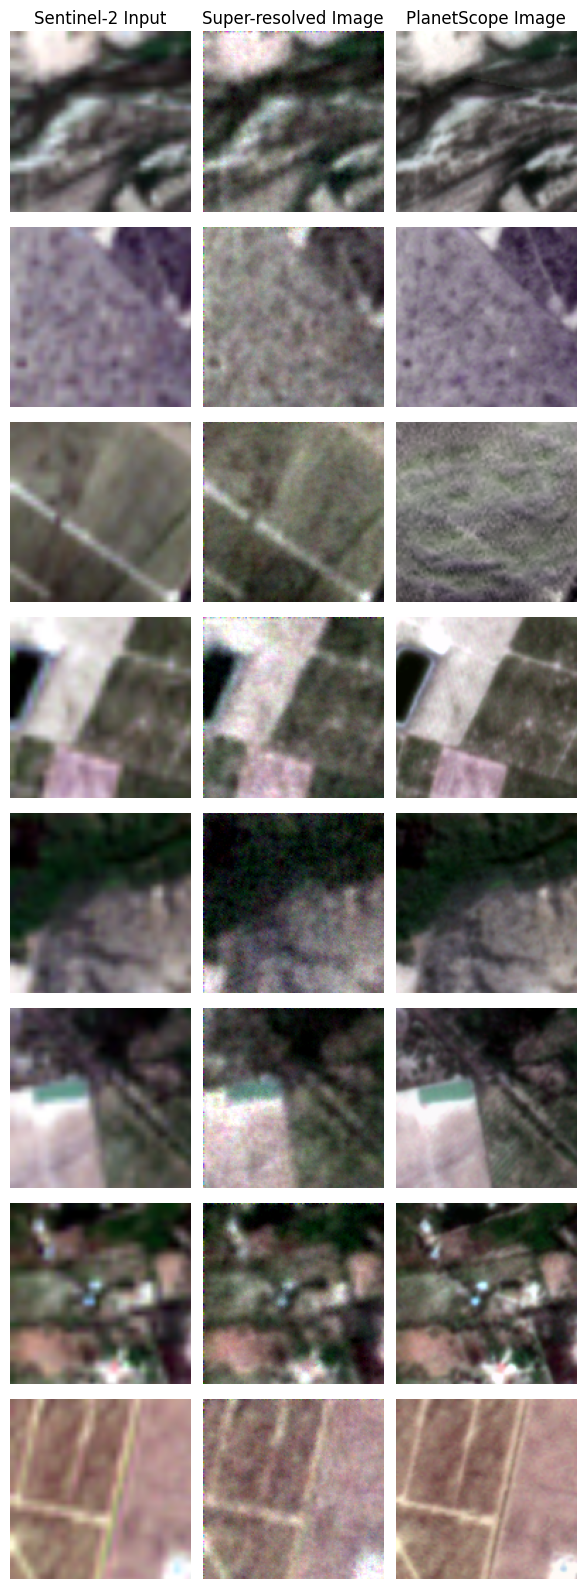

In [ ]:
# noise_scheduler.set_timesteps(num_inference_steps=50)

# model.load_state_dict(torch.load('../models/fm_s2_ps_sr.pt'))
model.eval()

batch_size = 8
num_inference_timesteps = 20

ps_img = torch.stack([val_dataset[i][1] for i in range(batch_size)], dim=0)

s2_img = torch.stack([val_dataset[i][0] for i in range(batch_size)], dim=0)
s2_img = F.interpolate(s2_img, size=ps_img.shape[-2:], mode='bilinear').to(device)

timesteps = torch.linspace(0, 1, num_inference_timesteps, device=device)
step_size = timesteps[1] - timesteps[0]

x = torch.randn_like(s2_img, device=device)
for t in tqdm(timesteps[:-1]):
    t_batch = torch.ones(batch_size, device=device) * t
    t_mid_batch = torch.ones(batch_size, device=device) * (t + step_size / 2)
    t_next_batch = torch.ones(batch_size, device=device) * (t + step_size)

    with torch.no_grad(), autocast(device.type, dtype=mixed_precision_dtype):
        
        # k1: velocity at start of the step
        model_input_k1 = torch.cat((x, s2_img), dim=1)
        v_k1 = model(model_input_k1, t_batch * 999).sample
        
        # k2: velocity at midpoint
        x_k2 = x + v_k1 * (step_size / 2)
        model_input_k2 = torch.cat((x_k2, s2_img), dim=1)
        v_k2 = model(model_input_k2, t_mid_batch * 999).sample
        
        # k3: velocity at midpoint (estimated with k2)
        x_k3 = x + v_k2 * (step_size / 2)
        model_input_k3 = torch.cat((x_k3, s2_img), dim=1)
        v_k3 = model(model_input_k3, t_mid_batch * 999).sample
        
        # k4: velocity at the end of the step
        x_k4 = x + v_k3 * step_size
        model_input_k4 = torch.cat((x_k4, s2_img), dim=1)
        v_k4 = model(model_input_k4, t_next_batch * 999).sample
    
    x = x + (step_size / 6) * (v_k1 + 2*v_k2 + 2*v_k3 + v_k4)
    
fig, axes = plt.subplots(batch_size, 3, figsize=(6, 2*batch_size))

for i, ax in enumerate(axes):
    
    # ax[0].imshow(s2_img)
    
    s2_img_display = (s2_img[i].clamp(-1, 1) + 1) / 2
    s2_img_display = s2_img_display.permute(1, 2, 0).cpu().numpy()
    s2_img_display = s2_img_display[:128, :128, :]
    ax[0].imshow(s2_img_display)
    
    output_display = (x[i].clamp(-1, 1) + 1) / 2
    output_display = output_display.permute(1, 2, 0).to(torch.float32).cpu().numpy()
    output_display = output_display[:128, :128, :]
    ax[1].imshow(output_display)
    
    ps_img_display = (ps_img[i].clamp(-1, 1) + 1) / 2
    ps_img_display = ps_img_display.permute(1, 2, 0).cpu().numpy()
    ps_img_display = ps_img_display[:128, :128, :]
    ax[2].imshow(ps_img_display)
    
    ax[0].axis('off')
    ax[1].axis('off')
    ax[2].axis('off')

axes[0][0].set_title('Sentinel-2 Input')
axes[0][1].set_title('Super-resolved Image')
axes[0][2].set_title('PlanetScope Image')

plt.tight_layout()
plt.show()